In [341]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
import xgboost as xgb


## CARGA DE DATOS Y PRIMERA VISIÓN DEL CONJUNTO

In [342]:
# Cargamos el dataset final de tintos. 

df = pd.read_csv("/Users/josetudela/Projects/vinos_grupo2/Proyecto_grupo2_vinos/FINAL_DF_TINTOS.csv")

In [343]:
#Info
df.shape

(20158, 20)

In [344]:
#Info
df.T.head

<bound method NDFrame.head of                                                                   0      \
Url                   https://www.vivino.com/ES/es/crealto-pionda/w/...   
ID                                                              3105259   
Nombre                                                           Pionda   
Año                                                                2018   
País                                                             Italia   
Región                                                       Monferrato   
Bodega                                                          Crealto   
Tipo de vino                                                 Vino tinto   
Uva                                                            Nebbiolo   
Precio                                                            32.53   
Valoración                                                          3.8   
Contenido de alcohol                                                  

## TRATAMIENTO DE DATOS PARA TENER EL DATASET LIMPIO Y CON LA ESTRUCTURA BUSCADA

In [345]:
# Modificamos maridaje porque contiene una "," en medio de la descrpción 

def limpiar_caza(texto):
    if isinstance(texto, str) and "caza" in texto.lower():  # Verifica si es texto y contiene "caza"
        return pd.Series(texto).replace(r"\s*\(.*?\)", "", regex=True).iloc[0]
    return texto  # Devuelve el texto sin cambios si no tiene "caza"

# Aplicar la limpieza a todas las celdas del DataFrame
df = df.applymap(limpiar_caza)

/var/folders/79/fd_qzfk141g8svblsrdwccqr0000gn/T/ipykernel_2754/211680032.py:9: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(limpiar_caza)


In [346]:
# Modificamos maridaje porque contiene una "," en medio de la descrpción 
def limpiar_pesca(texto):
    if isinstance(texto, str) and "azul " in texto.lower():  # Verifica si es texto y contiene "caza"
        return pd.Series(texto).replace(r"\s*\(.*?\)", "", regex=True).iloc[0]
    return texto  # Devuelve el texto sin cambios si no tiene "caza"

# Aplicar la limpieza a todas las celdas del DataFrame
df = df.applymap(limpiar_pesca)

/var/folders/79/fd_qzfk141g8svblsrdwccqr0000gn/T/ipykernel_2754/979100320.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(limpiar_pesca)


In [347]:
#Info
df.T

,0,1,2,3,4,5,6,7,8,9,...,20148,20149,20150,20151,20152,20153,20154,20155,20156,20157
Url,https://www.vivino.com/ES/es/crealto-pionda/w/...,https://www.vivino.com/ES/es/karpatska-perla-v...,https://www.vivino.com/ES/es/giachino-giac-pot...,https://www.vivino.com/ES/es/pelz-pinot-nero/w...,https://www.vivino.com/ES/es/finca-la-capilla-...,https://www.vivino.com/ES/es/suertes-del-marqu...,https://www.vivino.com/ES/es/attis-el-molinero...,https://www.vivino.com/ES/es/tenuta-ormanni-bo...,https://www.vivino.com/ES/es/alta-alella-orbus...,https://www.vivino.com/ES/es/chateau-combel-la...,...,https://www.vivino.com/ES/es/tommasi-le-prunee...,https://www.vivino.com/ES/es/milesi-poderi-le-...,https://www.vivino.com/ES/es/avgvstvs-cabernet...,https://www.vivino.com/ES/es/banfi-col-di-sass...,https://www.vivino.com/ES/es/covitoro-canus-ve...,https://www.vivino.com/ES/es/cantina-di-santad...,https://www.vivino.com/ES/es/es-nueva-crianza/...,https://www.vivino.com/ES/es/campestral-especi...,https://www.vivino.com/ES/es/portal-del-monsta...,https://www.vivino.com/ES/es/es-prohom-experie...
ID,3105259,1280319,6365197,2573275,1133110,5985946,6343332,1302561,2735037,3985319,...,7090,2608984,1692307,22913,1134541,17967,1210509,11571930,1437498,5731154
Nombre,Pionda,Varieto Frankovka Modrá,Giac' Potes,Pinot Nero,La Capilla Vendimia Seleccionada,Cruz Santa,El Molinero,Borro del Diavolo Riserva Chianti Classico,Orbus,Le Lac-aux-Cochons Cahors,...,Le Pruneé Merlot,Poderi le Cinte Curtefranca Rosso,Cabernet Sauvignon - Merlot,Col di Sasso (Cabernet Sauvignon - Sangiovese),Cañus Verus Viñas Viejas,Grotta Rossa Carignano del Sulcis,Crianza,Especial Tinto,Santes Negre Sustainable Vineyards,Prohom Experientia Negre
Año,2018,2021,2023,2020,2021,2020,2018,2021,2021,2021,...,2020,2022,2021,2022,2020,2022,2018,2020,No disponible,2021
País,Italia,Eslovaquia,Francia,Italia,España,España,España,Italia,España,Francia,...,Italia,Italia,España,Italia,España,Italia,España,España,España,España
Región,Monferrato,Malokarpatská,Savoie,Vigneti delle Dolomiti,Ribera del Duero,Valle de la Orotava,Rías Baixas,Chianti Classico,Alella,Cahors,...,delle Venezie,Curtefranca,Penedès,Toscana,Toro,Carignano del Sulcis,Rioja,Vino de España,Montsant,Terra Alta
Bodega,Crealto,Karpatská Perla,Domaine Giachino,Pelz,Finca La Capilla,Suertes del Marqués,Attis,Ormanni,Alta Alella,Château Combel La Serre,...,Tommasi,Milesi,Avgvstvs,Banfi,Covitoro,Santadi,Finca Nueva,Campestral,Portal del Montsant,Coma d'En Bonet
Tipo de vino,Vino tinto,Vino tinto,Vino tinto,Vino tinto,Vino tinto,Vino tinto,Vino tinto,Vino tinto,Vino tinto,Vino tinto,...,Vino tinto,Vino tinto,Vino tinto,Vino tinto,Vino tinto,Vino tinto,Vino tinto,Vino tinto,Vino tinto,Vino tinto
Uva,Nebbiolo,Blaufränkisch,"Gamay, Mondeuse Noire",Pinot Nero,Tinta del Pais,Vijariego Negro,Pinot Meunier,Sangiovese,Shiraz/Syrah,Malbec,...,Merlot,No disponible,"Cabernet Sauvignon, Merlot",Sangiovese,Tinta de toro,Carignan,Tempranillo,"Tintilla de Rota, Shiraz/Syrah, Cabernet Sauvi...",Ull de Llebre,"Shiraz/Syrah, Cabernet Sauvignon, Cariñena, Ga..."
Precio,32.53,32.52,32.52,32.50,32.50,32.50,32.50,32.50,32.50,32.50,...,10.88,10.88,10.88,10.86,9,12.40,10.85,10.85,8.51,10.85


In [348]:
#info
df.dtypes

Url                     object
ID                      object
Nombre                  object
Año                     object
País                    object
Región                  object
Bodega                  object
Tipo de vino            object
Uva                     object
Precio                  object
Valoración              object
Contenido de alcohol    object
Maridajes               object
Ligero/Poderoso         object
Suave/Tánico            object
Seco/Dulce              object
Débil/Ácido             object
Taste_Note_1            object
Taste_Note_2            object
Taste_Note_3            object
dtype: object

In [349]:
#Separamos la columna maridajes para que cada una sea una característica
df_maridaje_separado =  df["Maridajes"].str.split(',', expand=True)
df_maridaje_separado["ID"]= df["ID"]
df_maridaje_separado = df_maridaje_separado.fillna("Desconocido")
df_maridaje_separado[100:140]

,0,1,2,3,4,5,ID
100,Ternera,Cordero,Carne de caza,Desconocido,Desconocido,Desconocido,1181447
101,Ternera,Cordero,Pasta,Desconocido,Desconocido,Desconocido,1123194
102,Ternera,Cordero,Ternera lechal,Aves,Carne adobada,Desconocido,1420652
103,Ternera,Cordero,Aves,Pasta,Desconocido,Desconocido,2475833
104,Ternera,Cordero,Aves,Carne de caza,Desconocido,Desconocido,79640
105,Ternera lechal,Cerdo,Aves,Pasta,Carne de caza,Desconocido,1101307
106,Ternera,Cordero,Pasta,Carne de caza,Desconocido,Desconocido,1150701
107,Ternera lechal,Cerdo,Aves,Pasta,Carne de caza,Desconocido,1211200
108,Ternera,Cordero,Pasta,Carne de caza,Desconocido,Desconocido,1546843
109,Ternera,Ternera lechal,Aves,Carne de caza,Desconocido,Desconocido,2620585


In [350]:
# vemos los valores únicos para poder hacer one hot encoding. 
valores_unicos_maridaje = set(df_maridaje_separado.drop(columns=["ID"]).values.ravel())
print(valores_unicos_maridaje)

{'Carne de caza', 'Ternera', ' La comida basura vale', ' Ternera lechal', ' Cerdo', 'Maridajes', ' Queso tierno y cremoso', ' Pasta', ' Cordero', ' Aperitivos y tentempiés', 'No disponible', ' Comida picante', 'Aves', 'Ternera lechal', ' Pescado azul', ' Aves', ' Queso azul', ' Queso de leche de cabra', ' Champiñones', ' Carne adobada', 'Cordero', ' Carne de caza', ' Queso curado', ' Vegetariana', 'Cerdo', 'Pasta', ' Pescado blanco', 'Desconocido'}


In [351]:
#Info
len(valores_unicos_maridaje)

28

In [352]:
pd.get_dummies(df_maridaje_separado_sin_ID[[0,1]], prefix='', prefix_sep='')

,Aves,Carnedecaza,Cerdo,Cordero,Maridajes,Nodisponible,Pasta,Ternera,Terneralechal,Aperitivosytentempiés,Aves,Carneadobada,Carnedecaza,Cerdo,Cordero,Desconocido,Quesocurado,Terneralechal,Vegetariana
0,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False
1,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False
2,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False
3,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20153,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False
20154,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False
20155,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False
20156,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False


In [353]:
df_maridaje_separado_sin_ID

,0,1,2,3,4,5
0,Ternera,Cordero,Aves,Carnedecaza,Desconocido,Desconocido
1,Ternera,Cordero,Aves,Carnedecaza,Desconocido,Desconocido
2,Ternera,Carnedecaza,Quesocurado,Quesotiernoycremoso,Desconocido,Desconocido
3,Ternera,Terneralechal,Aves,Carnedecaza,Desconocido,Desconocido
4,Ternera,Cordero,Carnedecaza,Desconocido,Desconocido,Desconocido
...,...,...,...,...,...,...
20153,Ternera,Cordero,Pasta,Desconocido,Desconocido,Desconocido
20154,Ternera,Cordero,Terneralechal,Aves,Desconocido,Desconocido
20155,Ternera,Terneralechal,Aves,Pasta,Desconocido,Desconocido
20156,Ternera,Cordero,Pasta,Desconocido,Desconocido,Desconocido


In [354]:
df_maridaje_separado_sin_ID = df_maridaje_separado.drop(columns=["ID"])

df_maridaje_separado_sin_ID = df_maridaje_separado_sin_ID.applymap(lambda x: x.replace(" ", "") if isinstance(x, str) else x)
# Convertir todo el DataFrame a One-Hot Encoding sin prefijos por columna
df_maridaje_separado_sin_ID_encoded = pd.get_dummies(df_maridaje_separado_sin_ID,drop_first=True ,prefix="" ,prefix_sep="")

# Convertir a DataFrame
df_maridaje_separado_sin_ID_encoded = pd.DataFrame(df_maridaje_separado_sin_ID_encoded)

# Mostrar resultado
display(df_maridaje_separado_sin_ID_encoded)

/var/folders/79/fd_qzfk141g8svblsrdwccqr0000gn/T/ipykernel_2754/3108444008.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_maridaje_separado_sin_ID = df_maridaje_separado_sin_ID.applymap(lambda x: x.replace(" ", "") if isinstance(x, str) else x)


,Carnedecaza,Cerdo,Cordero,Maridajes,Nodisponible,Pasta,Ternera,Terneralechal,Aves,Carneadobada,...,Champiñones,Comidapicante,Desconocido,Lacomidabasuravale,Quesocurado,Quesodelechedecabra,Quesotiernoycremoso,Desconocido,Quesoazul,Quesodelechedecabra
0,False,False,False,False,False,False,True,False,False,False,...,False,False,True,False,False,False,False,True,False,False
1,False,False,False,False,False,False,True,False,False,False,...,False,False,True,False,False,False,False,True,False,False
2,False,False,False,False,False,False,True,False,False,False,...,False,False,True,False,False,False,False,True,False,False
3,False,False,False,False,False,False,True,False,False,False,...,False,False,True,False,False,False,False,True,False,False
4,False,False,False,False,False,False,True,False,False,False,...,False,False,True,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20153,False,False,False,False,False,False,True,False,False,False,...,False,False,True,False,False,False,False,True,False,False
20154,False,False,False,False,False,False,True,False,False,False,...,False,False,True,False,False,False,False,True,False,False
20155,False,False,False,False,False,False,True,False,False,False,...,False,False,True,False,False,False,False,True,False,False
20156,False,False,False,False,False,False,True,False,False,False,...,False,False,True,False,False,False,False,True,False,False


In [355]:
df_maridaje_separado_sin_ID_encoded.columns.nunique()

21

In [356]:
df_maridaje_separado_sin_ID_encoded=df_maridaje_separado_sin_ID_encoded.groupby(axis=1, level=0).sum()
df_maridaje_separado_encoded = df_maridaje_separado_sin_ID_encoded
df_maridaje_separado_encoded["ID"] = df["ID"]
df_maridaje_separado_encoded

/var/folders/79/fd_qzfk141g8svblsrdwccqr0000gn/T/ipykernel_2754/1026340629.py:1: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df_maridaje_separado_sin_ID_encoded=df_maridaje_separado_sin_ID_encoded.groupby(axis=1, level=0).sum()


,Aves,Carneadobada,Carnedecaza,Cerdo,Champiñones,Comidapicante,Cordero,Desconocido,Lacomidabasuravale,Maridajes,...,Pescadoazul,Pescadoblanco,Quesoazul,Quesocurado,Quesodelechedecabra,Quesotiernoycremoso,Ternera,Terneralechal,Vegetariana,ID
0,0,0,1,0,0,0,1,2,0,0,...,0,0,0,0,0,0,1,0,0,3105259
1,0,0,1,0,0,0,1,2,0,0,...,0,0,0,0,0,0,1,0,0,1280319
2,0,0,1,0,0,0,0,2,0,0,...,0,0,0,1,0,1,1,0,0,6365197
3,0,0,1,0,0,0,0,2,0,0,...,0,0,0,0,0,0,1,1,0,2573275
4,0,0,1,0,0,0,1,3,0,0,...,0,0,0,0,0,0,1,0,0,1133110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20153,0,0,0,0,0,0,1,3,0,0,...,0,0,0,0,0,0,1,0,0,17967
20154,1,0,0,0,0,0,1,2,0,0,...,0,0,0,0,0,0,1,1,0,1210509
20155,0,0,0,0,0,0,0,2,0,0,...,0,0,0,0,0,0,1,1,0,11571930
20156,0,0,0,0,0,0,1,3,0,0,...,0,0,0,0,0,0,1,0,0,1437498


In [357]:
#Separamos las notas de sabor en columnas diferentes. 

df_taste_1_separado = df["Taste_Note_1"].str.split(',', expand=True)
df_taste_1_separado


,0,1,2
0,Terroso,cuero,virutas...
1,cereza,frutos rojos,None
2,fresa,frambuesa,cerez...
3,No disponible,None,None
4,ciruela,fruta negra,c...
...,...,...,...
20153,Terroso,cuero,humo
20154,roble,vainilla,tabaco
20155,No disponible,None,None
20156,fruta negra,mora,arán...


In [358]:
#Separamos las notas de sabor en columnas diferentes. 

df_taste_2_separado = df["Taste_Note_2"].str.split(',', expand=True)
df_taste_2_separado

,0,1,2
0,fresa,cereza,arándano...
1,Terroso,piedra,None
2,casis,mora,fruta negr...
3,No disponible,None,None
4,roble,vainilla,tabaco
...,...,...,...
20153,cereza,frutos rojos,f...
20154,cereza,frutos rojos,c...
20155,No disponible,None,None
20156,cereza,frambuesa,fres...


In [359]:
#Separamos las notas de sabor en columnas diferentes. 

df_taste_3_separado = df["Taste_Note_3"].str.split(',', expand=True)
df_taste_3_separado

,0,1,2
0,frutos del bosque,merm...,None
1,chocolate,tabaco,vain...
2,Terroso,minerales,cue...
3,No disponible,None,None
4,cuero,Terroso,ceniza
...,...,...,...
20153,roble,chocolate,tabac...
20154,mora,cereza negra,cir...
20155,No disponible,None,None
20156,Terroso,carne a la par...,None


In [360]:
#Método "casero" para unir todas la notas de sabor separadas en un solo df
df_taste_1_separado[3] = df_taste_2_separado[0]
df_taste_1_separado[4] = df_taste_2_separado[1]
df_taste_1_separado[5] = df_taste_2_separado[2]
df_taste_1_separado[6] = df_taste_3_separado[0]
df_taste_1_separado[7] = df_taste_3_separado[1]
df_taste_1_separado[8] = df_taste_3_separado[2]
df_taste_1_separado["ID"] = df["ID"]
df_taste_1_separado


,0,1,2,3,4,5,6,7,8,ID
0,Terroso,cuero,virutas...,fresa,cereza,arándano...,frutos del bosque,merm...,None,3105259
1,cereza,frutos rojos,None,Terroso,piedra,None,chocolate,tabaco,vain...,1280319
2,fresa,frambuesa,cerez...,casis,mora,fruta negr...,Terroso,minerales,cue...,6365197
3,No disponible,None,None,No disponible,None,None,No disponible,None,None,2573275
4,ciruela,fruta negra,c...,roble,vainilla,tabaco,cuero,Terroso,ceniza,1133110
...,...,...,...,...,...,...,...,...,...,...
20153,Terroso,cuero,humo,cereza,frutos rojos,f...,roble,chocolate,tabac...,17967
20154,roble,vainilla,tabaco,cereza,frutos rojos,c...,mora,cereza negra,cir...,1210509
20155,No disponible,None,None,No disponible,None,None,No disponible,None,None,11571930
20156,fruta negra,mora,arán...,cereza,frambuesa,fres...,Terroso,carne a la par...,None,1437498


In [361]:
df_taste_1_separado[:1000].to_csv("df_taste_1_separado_0_1000.csv", index= False)

In [362]:
df_taste_1_separado_tijera = df_taste_1_separado.applymap(lambda x: None if isinstance(x, str) and x.endswith('.') else x)
df_taste_1_separado_tijera

/var/folders/79/fd_qzfk141g8svblsrdwccqr0000gn/T/ipykernel_2754/2875308546.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_taste_1_separado_tijera = df_taste_1_separado.applymap(lambda x: None if isinstance(x, str) and x.endswith('.') else x)


,0,1,2,3,4,5,6,7,8,ID
0,Terroso,cuero,None,fresa,cereza,None,frutos del bosque,None,None,3105259
1,cereza,frutos rojos,None,Terroso,piedra,None,chocolate,tabaco,None,1280319
2,fresa,frambuesa,None,casis,mora,None,Terroso,minerales,None,6365197
3,No disponible,None,None,No disponible,None,None,No disponible,None,None,2573275
4,ciruela,fruta negra,None,roble,vainilla,tabaco,cuero,Terroso,ceniza,1133110
...,...,...,...,...,...,...,...,...,...,...
20153,Terroso,cuero,humo,cereza,frutos rojos,None,roble,chocolate,None,17967
20154,roble,vainilla,tabaco,cereza,frutos rojos,None,mora,cereza negra,None,1210509
20155,No disponible,None,None,No disponible,None,None,No disponible,None,None,11571930
20156,fruta negra,mora,None,cereza,frambuesa,None,Terroso,None,None,1437498


In [363]:
df_taste_1_separado_tijera_sin_ID = df_taste_1_separado_tijera.drop(columns="ID")

In [364]:

# Convertir todo el DataFrame a One-Hot Encoding sin prefijos por columna
df_taste_1_one_hot_encoded = pd.get_dummies(df_taste_1_separado_tijera_sin_ID, prefix='', prefix_sep='')

# Convertir a DataFrame
df_taste_1_one_hot_encoded = pd.DataFrame(df_taste_1_one_hot_encoded)

df

# Mostrar resultado
display(df_taste_1_one_hot_encoded)

,Carne adobada,Carne de caza,No disponible,Polvo de 5 especias,Terroso,aceite,aceituna negra,aceto balsámico,agua de rosas,ajedrea,...,sándalo,sílex,tabaco,tiza,tofi,tomate,tomillo,vainilla,yogur,zarza
0,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20153,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
20154,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
20155,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
20156,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [365]:
df_taste_1_one_hot_encoded=df_taste_1_one_hot_encoded.groupby(axis=1, level=0).sum()
df_taste_1_one_hot_encoded

/var/folders/79/fd_qzfk141g8svblsrdwccqr0000gn/T/ipykernel_2754/770153049.py:1: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df_taste_1_one_hot_encoded=df_taste_1_one_hot_encoded.groupby(axis=1, level=0).sum()


,Carne adobada,Carne de caza,Terroso,acacia,aceite,aceite de coco,aceituna negra,acelga,aceto balsámico,agua de rosas,...,tostada,tropical,trufa negra,té Earl Grey,té Oolong,vainilla,violeta,virutas de lápiz,yogur,zarza
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20153,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
20154,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
20155,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
20156,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [366]:
df_taste_1_one_hot_encoded["ID"] = df["ID"]

In [367]:
a=15
conteo_valores_unicos_taste_serie = [(conteo_valores_unicos_taste>i).sum() for i in range(a)]
conteo_valores_unicos_taste_serie

[np.int64(503),
 np.int64(413),
 np.int64(367),
 np.int64(330),
 np.int64(295),
 np.int64(274),
 np.int64(261),
 np.int64(245),
 np.int64(232),
 np.int64(226),
 np.int64(217),
 np.int64(210),
 np.int64(201),
 np.int64(197),
 np.int64(193)]

In [368]:
mayor_que = list(range(0,a))
mayor_que

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]

Text(0.5, 1.0, 'palabras unicas vs filtro por > que')

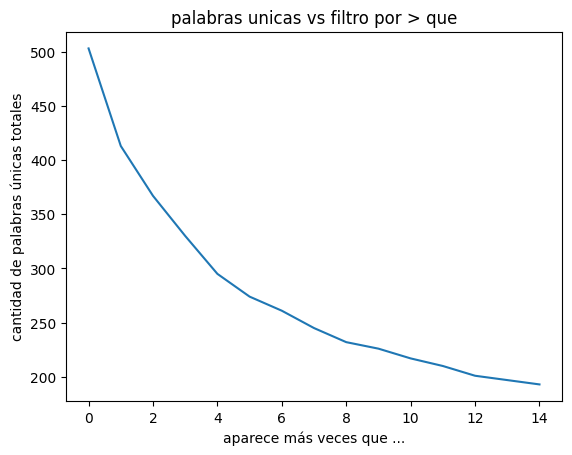

In [369]:
#Gráfico para apoyarnos si queremos eliminar palabras únicas que se repitan poco

plt.plot(mayor_que,conteo_valores_unicos_taste_serie,)
plt.xlabel('aparece más veces que ...')
plt.ylabel('cantidad de palabras únicas totales')
plt.title('palabras unicas vs filtro por > que')

In [370]:
df_merged_one_hot = pd.concat([df.set_index("ID"), df_maridaje_separado_encoded.set_index("ID"), df_taste_1_one_hot_encoded.set_index("ID")], axis=1).reset_index()

display(df_merged_one_hot.head())

,ID,Url,Nombre,Año,País,Región,Bodega,Tipo de vino,Uva,Precio,...,tostada,tropical,trufa negra,té Earl Grey,té Oolong,vainilla,violeta,virutas de lápiz,yogur,zarza
0,3105259,https://www.vivino.com/ES/es/crealto-pionda/w/...,Pionda,2018,Italia,Monferrato,Crealto,Vino tinto,Nebbiolo,32.53,...,0,0,0,0,0,0,0,0,0,0
1,1280319,https://www.vivino.com/ES/es/karpatska-perla-v...,Varieto Frankovka Modrá,2021,Eslovaquia,Malokarpatská,Karpatská Perla,Vino tinto,Blaufränkisch,32.52,...,0,0,0,0,0,0,0,0,0,0
2,6365197,https://www.vivino.com/ES/es/giachino-giac-pot...,Giac' Potes,2023,Francia,Savoie,Domaine Giachino,Vino tinto,"Gamay, Mondeuse Noire",32.52,...,0,0,0,0,0,0,0,0,0,0
3,2573275,https://www.vivino.com/ES/es/pelz-pinot-nero/w...,Pinot Nero,2020,Italia,Vigneti delle Dolomiti,Pelz,Vino tinto,Pinot Nero,32.50,...,0,0,0,0,0,0,0,0,0,0
4,1133110,https://www.vivino.com/ES/es/finca-la-capilla-...,La Capilla Vendimia Seleccionada,2021,España,Ribera del Duero,Finca La Capilla,Vino tinto,Tinta del Pais,32.50,...,0,0,0,0,0,0,0,0,0,0


In [371]:
df_merged_one_hot=df_merged_one_hot.drop(index=5264)

In [372]:
df_merged_one_hot["ID"] = df_merged_one_hot["ID"].astype(int)

In [373]:
df_merged_one_hot = df_merged_one_hot.drop(columns=["Tipo de vino","Url"])

In [337]:
df_merged_one_hot[["Nombre","País","Región","Bodega","Uva"]] = df_merged_one_hot[["Nombre","País","Región","Bodega","Uva"]].astype(str)

In [374]:
df_merged_one_hot

,ID,Nombre,Año,País,Región,Bodega,Uva,Precio,Valoración,Contenido de alcohol,...,tostada,tropical,trufa negra,té Earl Grey,té Oolong,vainilla,violeta,virutas de lápiz,yogur,zarza
0,3105259,Pionda,2018,Italia,Monferrato,Crealto,Nebbiolo,32.53,3.8,5,...,0,0,0,0,0,0,0,0,0,0
1,1280319,Varieto Frankovka Modrá,2021,Eslovaquia,Malokarpatská,Karpatská Perla,Blaufränkisch,32.52,3.5,13,...,0,0,0,0,0,0,0,0,0,0
2,6365197,Giac' Potes,2023,Francia,Savoie,Domaine Giachino,"Gamay, Mondeuse Noire",32.52,3.8,No disponible,...,0,0,0,0,0,0,0,0,0,0
3,2573275,Pinot Nero,2020,Italia,Vigneti delle Dolomiti,Pelz,Pinot Nero,32.50,3.8,No disponible,...,0,0,0,0,0,0,0,0,0,0
4,1133110,La Capilla Vendimia Seleccionada,2021,España,Ribera del Duero,Finca La Capilla,Tinta del Pais,32.50,4.3,15,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20153,17967,Grotta Rossa Carignano del Sulcis,2022,Italia,Carignano del Sulcis,Santadi,Carignan,12.40,3.6,14,...,0,0,0,0,0,0,0,0,0,0
20154,1210509,Crianza,2018,España,Rioja,Finca Nueva,Tempranillo,10.85,3.7,13,...,0,0,0,0,0,0,0,0,0,0
20155,11571930,Especial Tinto,2020,España,Vino de España,Campestral,"Tintilla de Rota, Shiraz/Syrah, Cabernet Sauvi...",10.85,3.7,13,...,0,0,0,0,0,0,0,0,0,0
20156,1437498,Santes Negre Sustainable Vineyards,No disponible,España,Montsant,Portal del Montsant,Ull de Llebre,8.51,3.5,5,...,0,0,0,0,0,0,0,0,0,0


In [196]:
X= df_merged_one_hot.drop(columns="Valoración")
y = df_merged_one_hot["Valoración"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [375]:
df_merged_one_hot = df_merged_one_hot.drop((df_merged_one_hot["Precio"]=="No disponible").index)

In [376]:
df_merged_one_hot

,ID,Nombre,Año,País,Región,Bodega,Uva,Precio,Valoración,Contenido de alcohol,...,tostada,tropical,trufa negra,té Earl Grey,té Oolong,vainilla,violeta,virutas de lápiz,yogur,zarza


In [226]:
df_merged_one_hot[["Precio", "Valoración", "Contenido de alcohol"]] = df_merged_one_hot[["Precio", "Valoración", "Contenido de alcohol"]].astype(float) 

ValueError: could not convert string to float: 'No disponible'

In [221]:
df_merged_one_hot.dtypes

ID                   int64
Nombre              object
Año                 object
País                object
Región              object
                     ...  
vainilla             int64
violeta              int64
virutas de lápiz     int64
yogur                int64
zarza                int64
Length: 542, dtype: object

In [193]:
# filtramos por variables por orden de importancia
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42).fit(X_train, y_train)
df_imp = pd.DataFrame({'Feature':X_train.columns, 'Importance':xgb_model.feature_importances_*100})
df_imp = df_imp.sort_values(by='Importance', ascending=False)
df_imp

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:ID: object, Url: object, Nombre: object, Año: object, País: object, Región: object, Bodega: object, Tipo de vino: object, Uva: object, Precio: object, Contenido de alcohol: object, Maridajes: object, Ligero/Poderoso: object, Suave/Tánico: object, Seco/Dulce: object, Débil/Ácido: object, Taste_Note_1: object, Taste_Note_2: object, Taste_Note_3: object